


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (instacart_orders.csv, products.csv, aisles.csv, departments.csv e order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [1]:
# Importe as bibliotecas
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# leia os conjuntos de dados em DataFrames
df_instacart_orders = pd.read_csv('instacart_orders.csv', sep = ';')
df_products = pd.read_csv('products.csv', sep = ';')
df_order_products = pd.read_csv('order_products.csv', sep = ';')
df_aisles = pd.read_csv('aisles.csv', sep = ';')
df_departments = pd.read_csv('departments.csv', sep = ';')

In [3]:
# imprima as informações sobre o DataFrame
print(df_instacart_orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [4]:
# imprima as informações sobre o DataFrame
print(df_products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [5]:
# imprima as informações sobre o DataFrame
print(df_order_products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


In [6]:
# imprima as informações sobre o DataFrame
print(df_aisles.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [7]:
# imprima as informações sobre o DataFrame
print(df_departments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
None


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados.

**Todos os dataframes aparentam ter uma estrutura básica bem organizada, porém pode-se pecerbar que há alguns valores vazios em algumas colunas de certosdataframes, assim sendo necessário realizar um tratamento de dados para garantir uma análise mais precisa.**

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados

**Esta etapa será reservada para eu processar e preparar os dados para seu uso final. Irei identificar e apagar dados repetidos, renomear dados incorretamente escritos, etc.**

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [8]:
# Verificar se há pedidos duplicados
df_instacart_orders_duplicates = df_instacart_orders[df_instacart_orders.duplicated()]
df_instacart_orders_duplicates_sum = df_instacart_orders.duplicated().sum()
print(df_instacart_orders_duplicates)
print()
print(df_instacart_orders_duplicates_sum)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

Há linhas duplicadas? Se sim, o que elas têm em comum?

**Há 15 linhas classificadas como duplicadas, e todas essas possuem o dia da semana e a hora em que o pedido foi realizado em comum.**

In [9]:
# Com base nas suas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

df_instacart_orders_filtered = df_instacart_orders[(df_instacart_orders['order_dow'] == 3) & (df_instacart_orders['order_hour_of_day'] == 2)]

print(df_instacart_orders_filtered)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

O que esse resultado quer dizer?

**De todas as 121 linhas deste dataframe, 15 delas se repetem pelo menos uma vez.**

In [10]:
# Remova pedidos duplicados

df_instacart_orders = df_instacart_orders.drop_duplicates().reset_index(drop = True)

In [11]:
# Verifique as linhas duplicadas mais uma vez

df_instacart_orders_duplicates = df_instacart_orders[df_instacart_orders.duplicated()]
df_instacart_orders_duplicates_sum = df_instacart_orders.duplicated().sum()
print(df_instacart_orders_duplicates)
print()
print(df_instacart_orders_duplicates_sum)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []

0


In [12]:
# Verifique novamente apenas os IDs de pedidos duplicados

print(df_instacart_orders_duplicates['order_id'])

Series([], Name: order_id, dtype: int64)




Descreva brevemente suas conclusões e o que você fez com elas.

**Não há linhas duplicadas neste dataframe.**

### DataFrame `products`

In [13]:
# Verifique se há linhas completamente duplicadas

df_products_duplicates = df_products[df_products.duplicated()]
df_products_duplicates_sum = df_products.duplicated().sum()
print(df_products_duplicates)
print()
print(df_products_duplicates_sum)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []

0


In [14]:
# Verifique apenas IDs dos produtos duplicados

print(df_products_duplicates['product_id'])

Series([], Name: product_id, dtype: int64)


In [15]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)

df_products_duplicates['product_name'] = df_products_duplicates['product_name'].str.title()

print(df_products_duplicates['product_name'])

Series([], Name: product_name, dtype: object)


In [16]:
# Verifique os nomes de produtos duplicados que não estão faltando

print(df_products[df_products['product_name'].notna() & df_products.duplicated('product_name', keep = False)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.

**Descobri que não aparenta haver valores duplicados neste dataframe.**

### DataFrame `departments`

In [17]:
# Verifique se há linhas completamente duplicadas

df_departments_duplicates = df_departments[df_departments.duplicated()]
print(df_departments_duplicates)

Empty DataFrame
Columns: [department_id, department]
Index: []


In [18]:
# Verifique apenas se há IDs dos produtos duplicados

print(df_departments_duplicates['department_id'])

Series([], Name: department_id, dtype: int64)


Descreva brevemente suas conclusões e o que você fez com elas.

**Descobri que não aparenta haver valores duplicados neste dataframe.**

### DataFrame `aisles`

In [19]:
# Verifique se há linhas completamente duplicadas

df_aisles_duplicates = df_aisles[df_aisles.duplicated()]
print(df_aisles_duplicates)

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


In [20]:
# Verifique apenas se há IDs dos produtos duplicados

print(df_aisles_duplicates['aisle_id'])

Series([], Name: aisle_id, dtype: int64)


Descreva brevemente suas conclusões e o que você fez com elas.

**Descobri que não aparenta haver valores duplicados neste dataframe.**

### DataFrame `order_products`

In [21]:
# Verifique se há linhas completamente duplicadas
df_order_products_duplicates = df_order_products[df_order_products.duplicated()]
print(df_order_products_duplicates)

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [22]:
# Verifique mais uma vez se há outros casos complicados de duplicados
df_duplicated_subset = df_order_products[df_order_products.duplicated(subset=['product_id', 'order_id'])]

print(df_duplicated_subset)

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.

**Descobri que não aparenta haver valores duplicados neste dataframe.**

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [23]:
# Encontre valores ausentes na coluna 'product_name'

print(df_products[df_products['product_name'].isna()])
print()
print(df_products['product_name'].isna().sum())

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]

1258


Descreva brevemente suas conclusões.

**Há 1258 valoes ausentes na coluna 'product_name'.**

In [24]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?

nan_on_aisle_100 = df_products[(df_products['product_name'].isna()) & (df_products['aisle_id'] == 100)]

print(nan_on_aisle_100)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Descreva brevemente suas conclusões.

**Das 1258 linhas com valores ausentes, nenhuma delas foi excluida ao filtar apenas os valores ausentes no corredor 100, ou seja, todos os nomes ausentes tem sim relação com o corredor 100.**

In [25]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?

nan_on_department_21 = df_products[(df_products['product_name'].isna()) & (df_products['department_id'] == 21)]

print(nan_on_department_21)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Descreva brevemente suas conclusões.

**Das 1258 linhas com valores ausentes, nenhuma delas foi excluida ao filtar apenas os valores ausentes no departamento 21, ou seja, todos os nomes ausentes tem sim relação com o departamento 21.**

In [26]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.

aisle_100_and_department_21 = df_products[(df_products['aisle_id'] == 100) & (df_products['department_id'] == 21)]

print(aisle_100_and_department_21)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Descreva brevemente suas conclusões.

**Todos os nomes dos produtos presentes no corredor 100 do departamento 21 estão vazios.**

In [27]:
# Preencha nomes de produtos ausentes com 'Unknown'

df_products['product_name'] = df_products['product_name'].fillna(value = 'Unknown')

print(df_products[(df_products['aisle_id'] == 100) & (df_products['department_id'] == 21)])
print(df_products['product_name'].isna().sum())

       product_id product_name  aisle_id  department_id
37             38      Unknown       100             21
71             72      Unknown       100             21
109           110      Unknown       100             21
296           297      Unknown       100             21
416           417      Unknown       100             21
...           ...          ...       ...            ...
49552       49553      Unknown       100             21
49574       49575      Unknown       100             21
49640       49641      Unknown       100             21
49663       49664      Unknown       100             21
49668       49669      Unknown       100             21

[1258 rows x 4 columns]
0


Descreva brevemente suas conclusões e o que você fez com elas.

**Descobri que todos os nomes dos produtos relacionados ao corredor 100 e ao departamento 21 estavam vazios, por isso eu substituí todos os valores ausentes por 'Unknown'.**

### DataFrame `orders`

In [28]:
# Encontre os valores ausentes
print(df_instacart_orders[df_instacart_orders['days_since_prior_order'].isna()])
print()
print(df_instacart_orders['days_since_prior_order'].isna().sum())

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478880   2589657   205028             1          0                 16   
478881   2222353   141211             1          2                 13   
478907   2272807   204154             1          1                 15   
478911   2499542    68810             1          4                 19   
478930   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [29]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?

nan_on_first_order = df_instacart_orders[(df_instacart_orders['days_since_prior_order'].isna()) & (~df_instacart_orders['order_number'] == 1)]

print(nan_on_first_order)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.

**Aparentemente todos os valores ausentes em 'days_since_prior_order' vem apenas de clientes que fizeram o primeiro pedido.**

### DataFrame `order_products`

In [30]:
# Encontre os valores ausentes

print(df_order_products[df_order_products['add_to_cart_order'].isna()])
print()
print(df_order_products['add_to_cart_order'].isna().sum())

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]

836


In [31]:
# Quais são os valores mínimo e máximo dessa coluna?

print(df_order_products['add_to_cart_order'].min())
print()
print(df_order_products['add_to_cart_order'].max())

1.0

64.0


Descreva brevemente suas conclusões.

**O valor mínimo e máximo de 'add_to_cart_order' é 1.0 e 64.0 respectivamente.**

In [32]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'

nan_value_ids = df_order_products[(df_order_products['add_to_cart_order'].isna()) & (df_order_products['order_id'])]

print(nan_value_ids['order_id'].value_counts())

order_id
61355      63
2136777    44
1959075    34
1730767    31
1800005    28
2926893    28
1386261    27
3125735    22
2721963    22
1968313    16
1673227    14
1832957    14
293169     13
844733     13
404157     12
1183255    11
871281     10
1021563     9
2479011     9
1961723     9
2094761     9
2256933     7
3347453     7
2999801     6
1648217     6
165801      6
1169835     5
1564093     5
2409109     5
129627      5
2997021     4
1477139     4
1633337     3
854647      3
1302315     3
1308785     2
2979697     2
1625713     2
1529171     2
1598369     1
2621907     1
2170451     1
Name: count, dtype: int64


In [33]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?

order_id_size = df_order_products['order_id'].value_counts()
order_id_size = order_id_size[order_id_size > 64].index
order_id_size_nan = df_order_products[(df_order_products['add_to_cart_order'].isna()) & (df_order_products['order_id'].isin(order_id_size))]

# Agrupe os pedidos com dados ausentes por ID de pedido

nan_ids = df_order_products[df_order_products['add_to_cart_order'].isna()]['order_id'].value_counts()

# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem

products_per_order = df_order_products.groupby('order_id')['product_id'].count()
min_products_in_order = products_per_order.min()

print(order_id_size_nan)
print()
print(nan_ids)
print()
print(min_products_in_order)

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]

order_id
61355      63
3308010    51
2136777    44
171934     40
1959075    34
           ..
888470      1
2621907     1
2729254     1
9310        1
2170451     1
Name: count, Length: 70, dtype: int64

1


Descreva brevemente suas conclusões.

A. **Não, nenhum valor com valor ausente contém mais de 64 produtos, o maior pedido dessa filtagem possui 63 produtos.**

B. **Há 70 ids de pedidos com valores ausentes.**

C. **O valor mínimo é 1.**

In [34]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer

df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].fillna(value = 999).astype(int)
print(df_order_products[df_order_products['add_to_cart_order'].isna()])
print(df_order_products[df_order_products['add_to_cart_order'] == 999])

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []
         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                999          0
9926      1968313       43867                999          0
14394     2926893       11688                999          0
16418     1717990        4142                999          0
30114     1959075       42828                999          1
...           ...         ...                ...        ...
4505662   1800005        7411                999          0
4511400   1633337         260                999          0
4517562    404157        9517                999          0
4534112   1673227       17835                999          0
4535739   1832957       17949                999          1

[836 rows x 4 columns]


Descreva brevemente suas conclusões e o que você fez com elas.

**De todas as linhas deste dataframe, 186 delas possuem o valor vazio na coluna 'add_to_cart_order', valores esses que foram substituidos por '999', assim eliminando o valores vazios.**

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados.

**Foram realizadas filtragens e correções nos dados para que eles possam ser melhor analizados na Etapa 3.**

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [35]:
print(df_instacart_orders['order_hour_of_day'].value_counts().sort_index())

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: count, dtype: int64


In [36]:
print(df_instacart_orders['order_dow'].value_counts().sort_index())

order_dow
0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: count, dtype: int64


Escreva suas conclusões aqui

**Como pode-se ver pelos métodos value_counts() e sort_index(), os valores de 'order_hour_of_day' e 'order_dow' de fato variam entre os valores mínimos e máximos.**

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

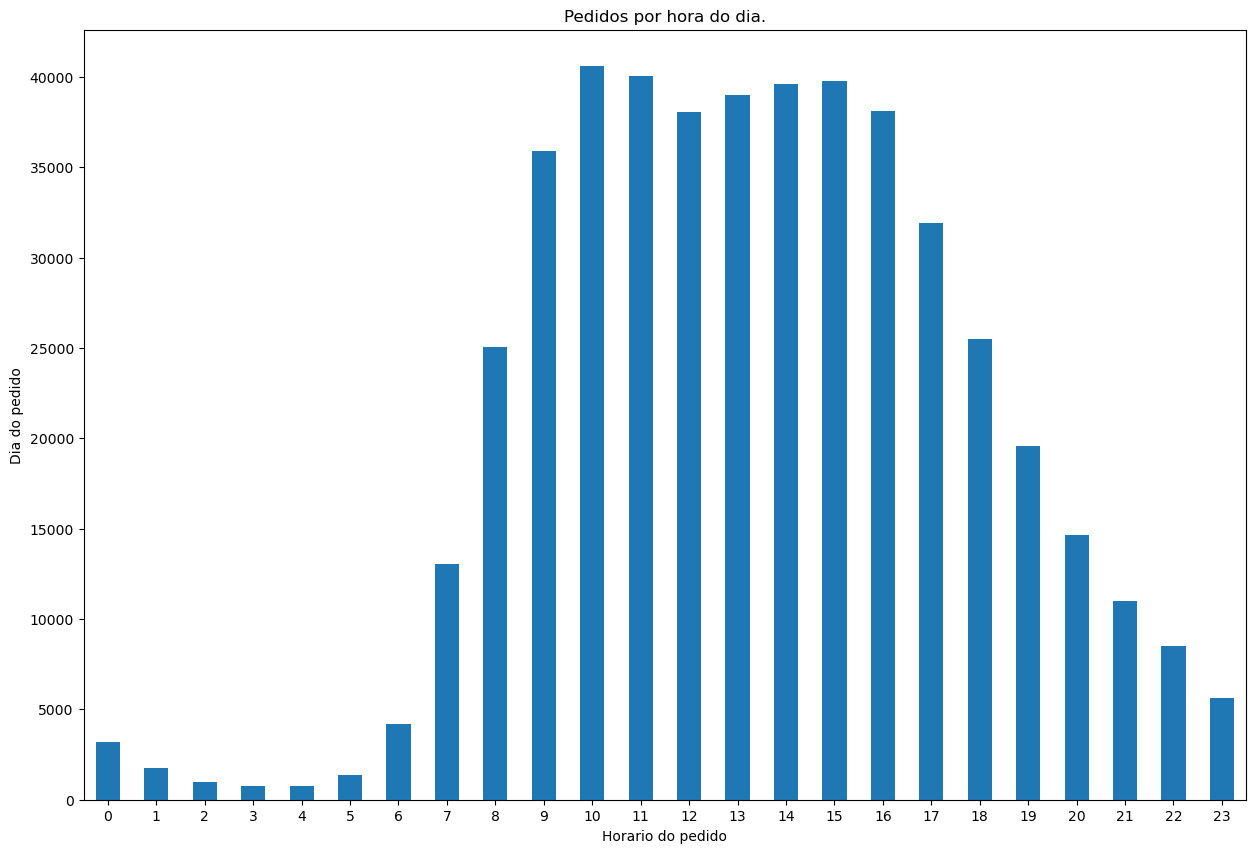

In [37]:
df_instacart_orders['order_hour_of_day'].value_counts().sort_index().plot(
                         title = 'Pedidos por hora do dia.',
                         xlabel='Horario do pedido',
                         ylabel='Dia do pedido',
                         kind = 'bar',
                         xlim = [0,23],
                         rot = 0,
                         figsize = [15, 10])
plt.show()

Escreva suas conclusões aqui

**Pessoas fazem mais compras pelas 10 da manhã e menos as 4 da manhã.**

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

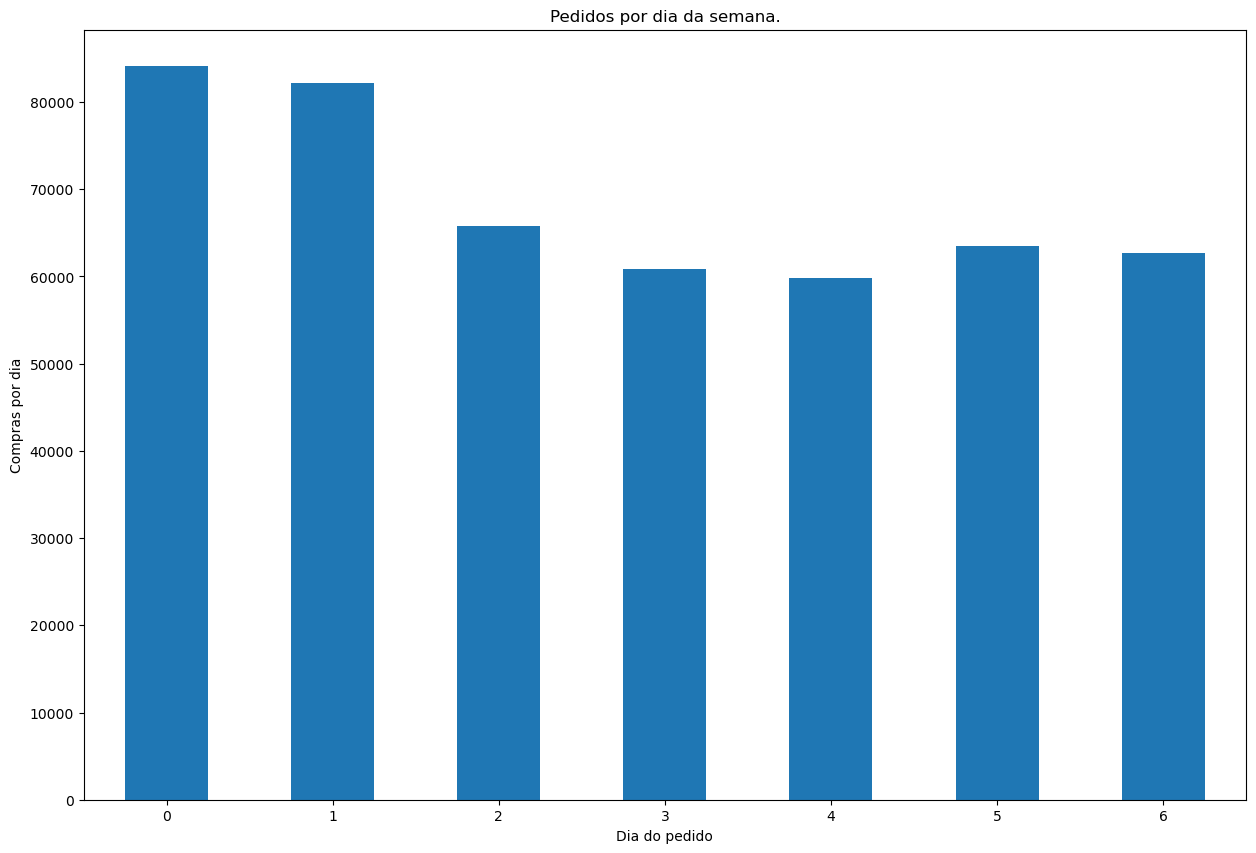

In [38]:
df_instacart_orders['order_dow'].value_counts().sort_index().plot(
                         title = 'Pedidos por dia da semana.',
                         xlabel='Dia do pedido',
                         ylabel='Compras por dia',
                         kind = 'bar',
                         xlim = [0,6],
                         rot = 0,
                         figsize = [15, 10]
)

plt.show()

Escreva suas conclusões aqui

**Clientes fazem mais compras pelos domingos.**

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

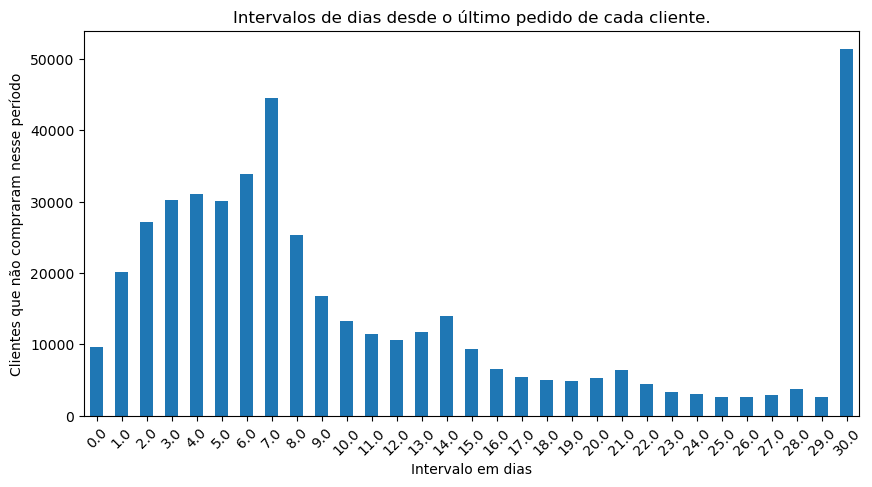

In [39]:
df_instacart_orders['days_since_prior_order'].value_counts().sort_index().plot(
    title = 'Intervalos de dias desde o último pedido de cada cliente.',
    xlabel = 'Intervalo em dias',
    ylabel = 'Clientes que não compraram nesse período',
    kind = 'bar',
    rot = 45,
    figsize = [10,5]
)

plt.show()

Escreva suas conclusões aqui

**A maioria dos clientes tem um intervalo de 30 dias antes de fazer um novo pedido enquando a minoria dos mesmos tem um intervalo de 26 dias.**

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

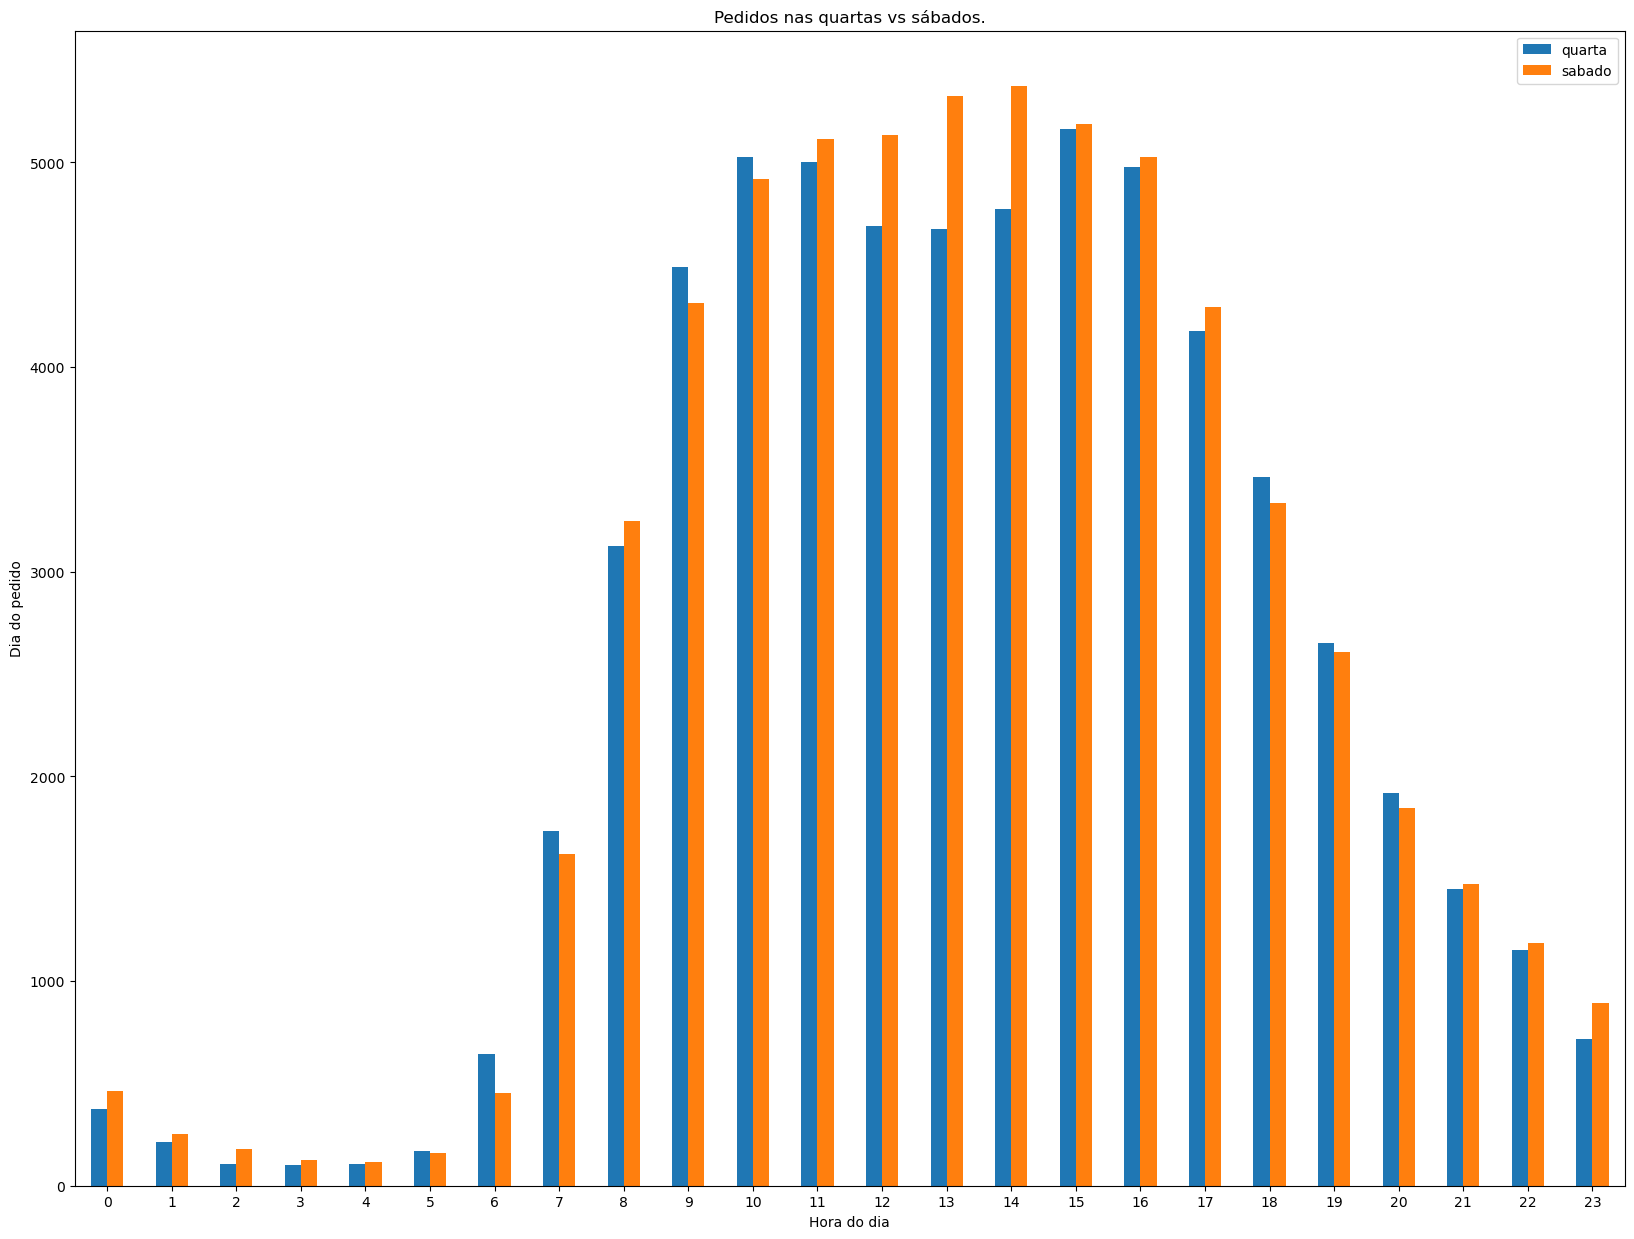

In [40]:
#GRÁFICO COM OS DOIS DIAS JUNTOS.
df_wednesday = df_instacart_orders[df_instacart_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()

df_saturday = df_instacart_orders[df_instacart_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

pd.DataFrame({'quarta': df_wednesday, 'sabado': df_saturday}).plot(
                         title = 'Pedidos nas quartas vs sábados.',
                         xlabel='Hora do dia',
                         ylabel='Dia do pedido',
                         kind = 'bar',
                         rot = 0,
                         xlim = [0,23],
                         figsize = [20,15])
#
plt.show()

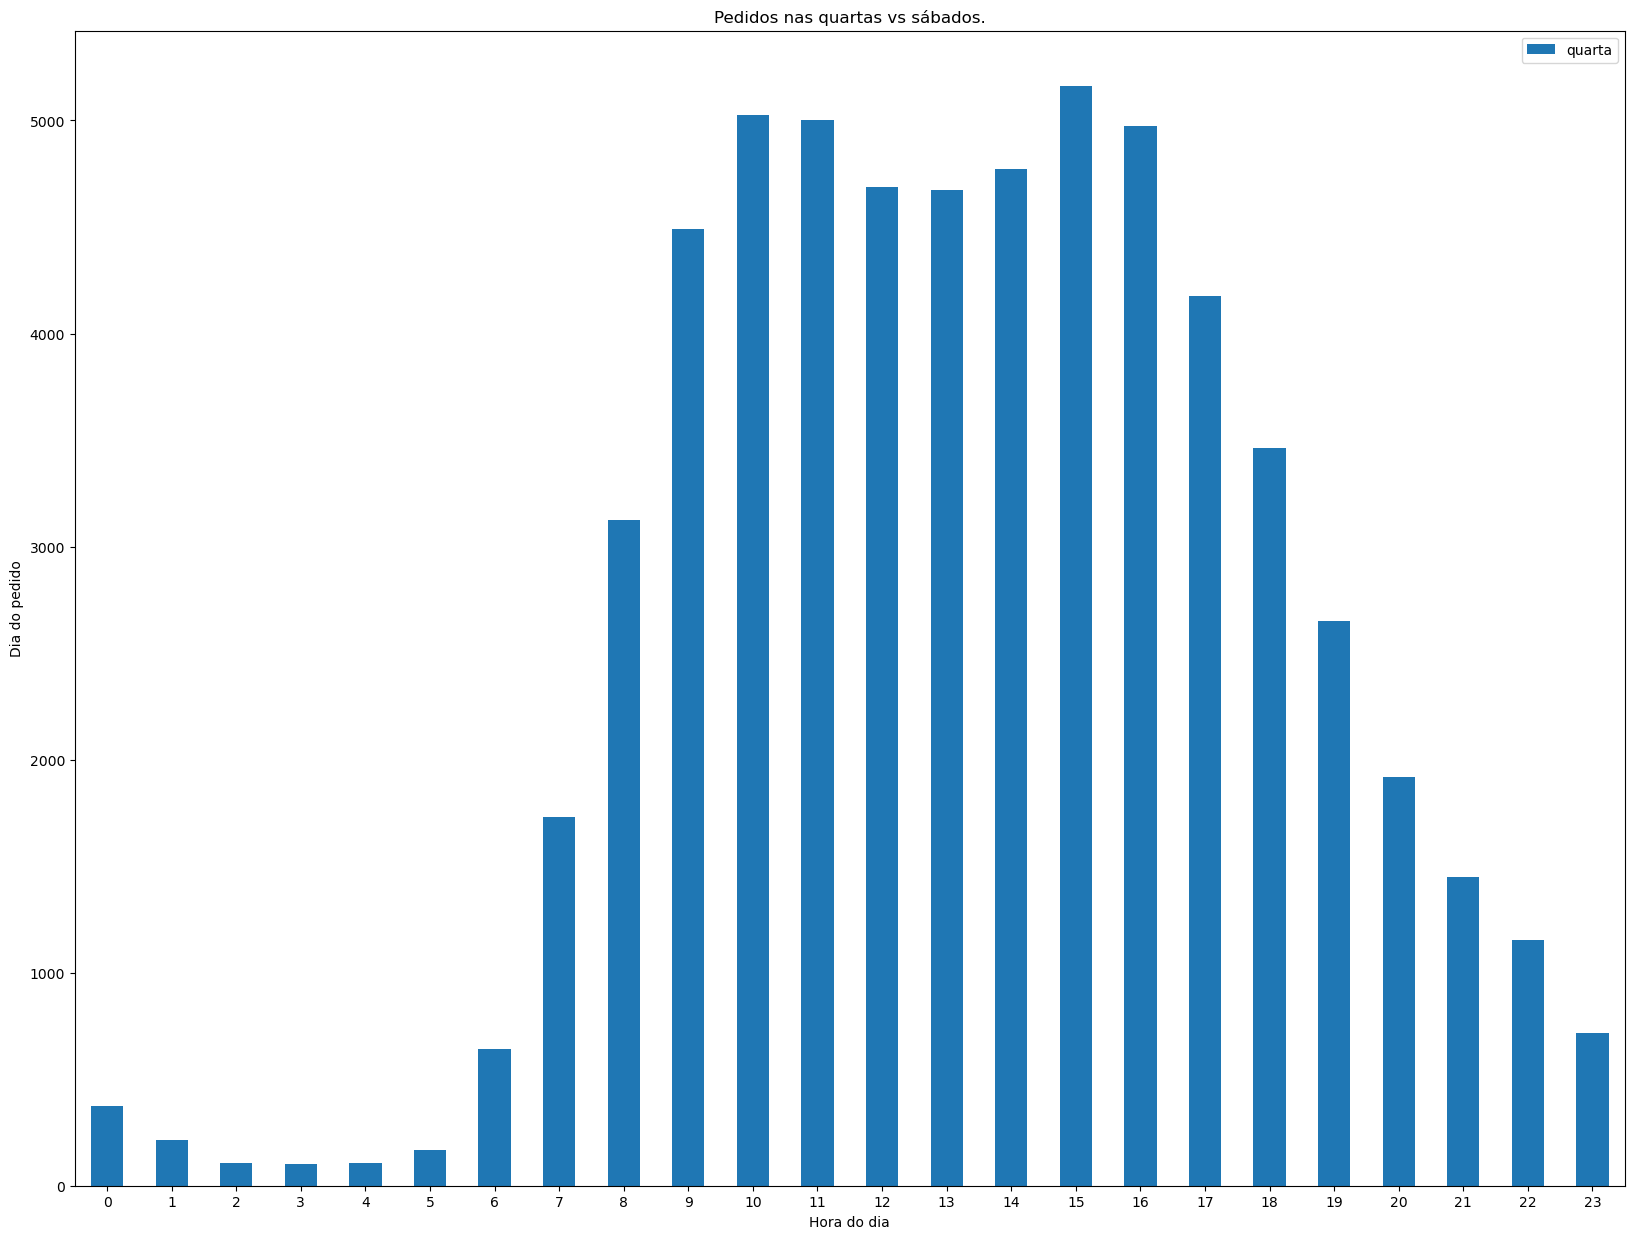

In [41]:
#GRÁFICO APENAS DE QUARTA
pd.DataFrame({'quarta': df_wednesday}).plot(
                         title = 'Pedidos nas quartas vs sábados.',
                         xlabel='Hora do dia',
                         ylabel='Dia do pedido',
                         kind = 'bar',
                         rot = 0,
                         xlim = [0,23],
                         figsize = [20,15])

plt.show()

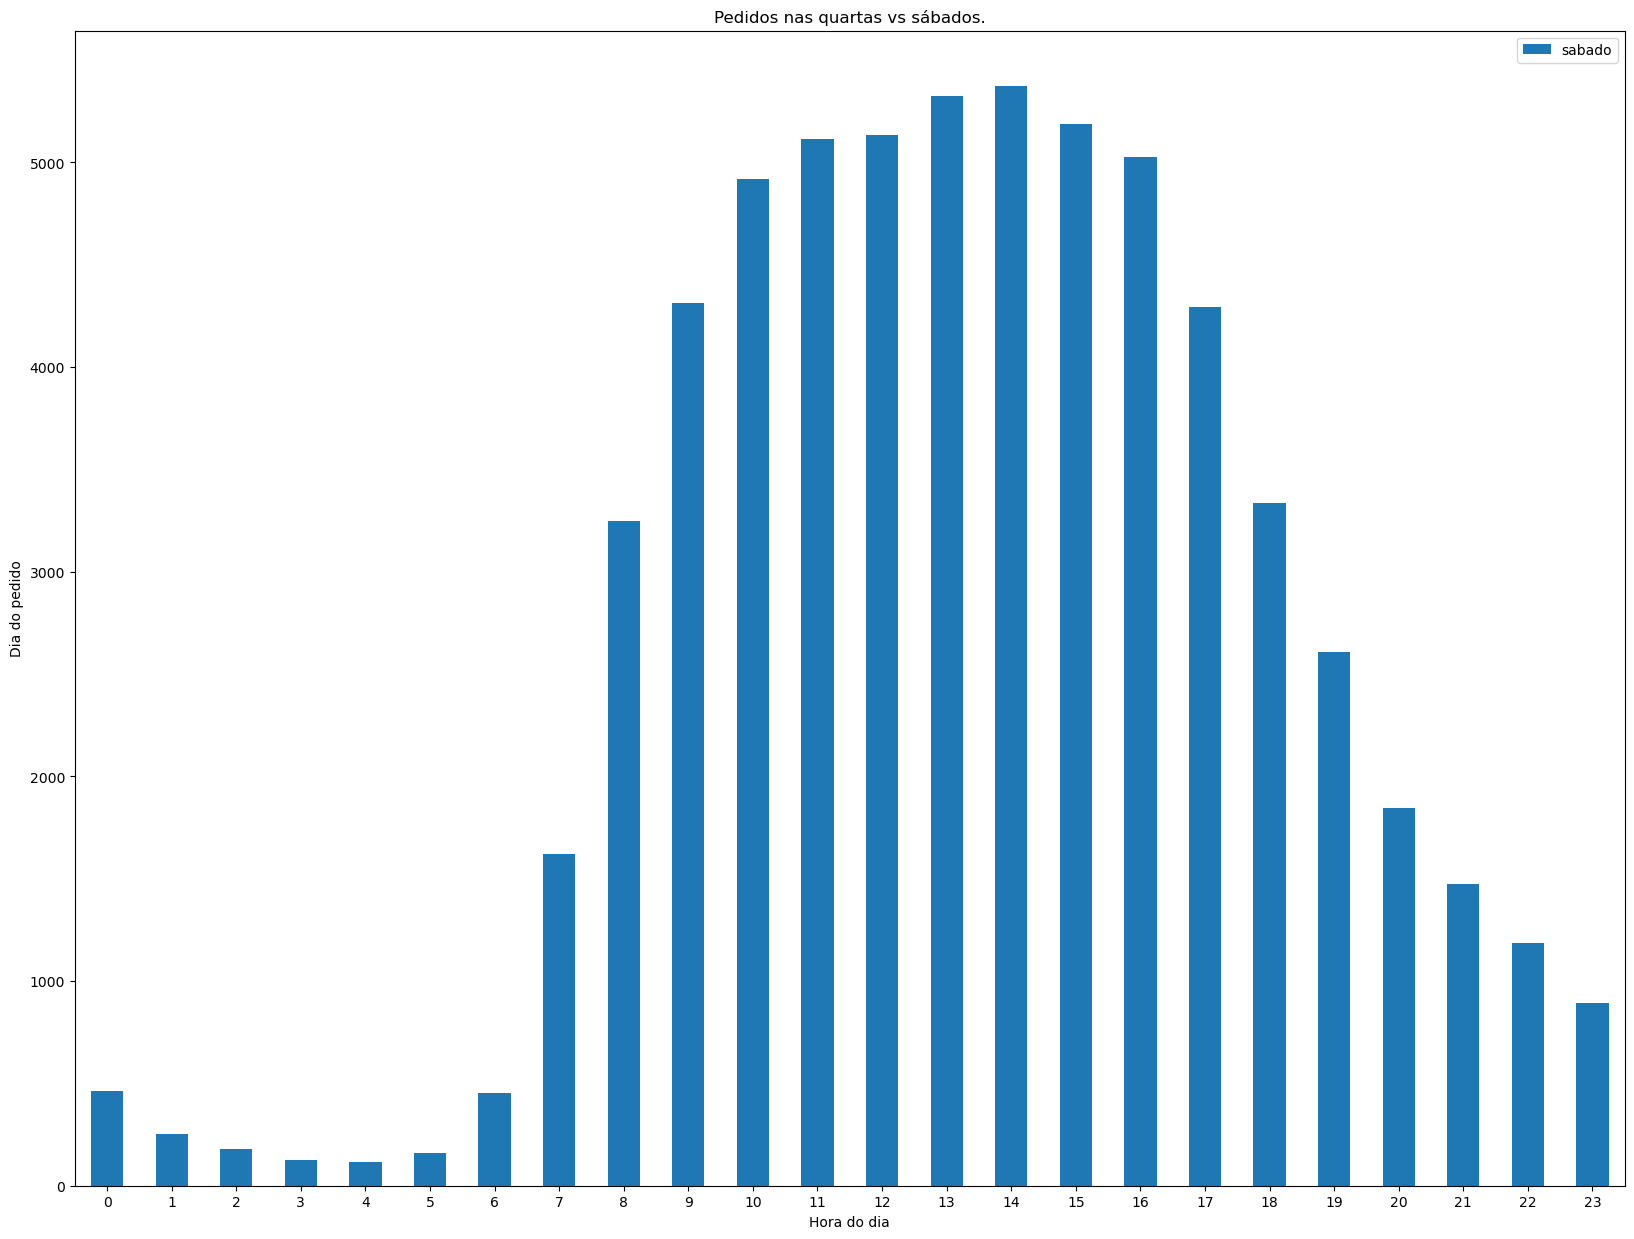

In [42]:
#GRÁFICO APENAS DE SÁBADO
pd.DataFrame({'sabado': df_saturday}).plot(
                         title = 'Pedidos nas quartas vs sábados.',
                         xlabel='Hora do dia',
                         ylabel='Dia do pedido',
                         kind = 'bar',
                         rot = 0,
                         xlim = [0,23],
                         figsize = [20,15])

plt.show()

Escreva suas conclusões aqui

**Pode-se perceber que os clientes compram mais nos sábados pelos seguintes horários:**
*Da meia-noite até as 4 da manhã, ás 8 da manhã, das 11 da manhã até ás 5 da tarde e das 9 até ás 11 da noite.*

**E consequntemente isso significa que ás quartas os clientes fazem compras:**
*Das 5 até ás 7 da manhã, das 9 ás 10 da manhã e das 6 da tarde até ás 8 da noite.*

### [B2] Qual é a distribuição do número de pedidos por cliente?

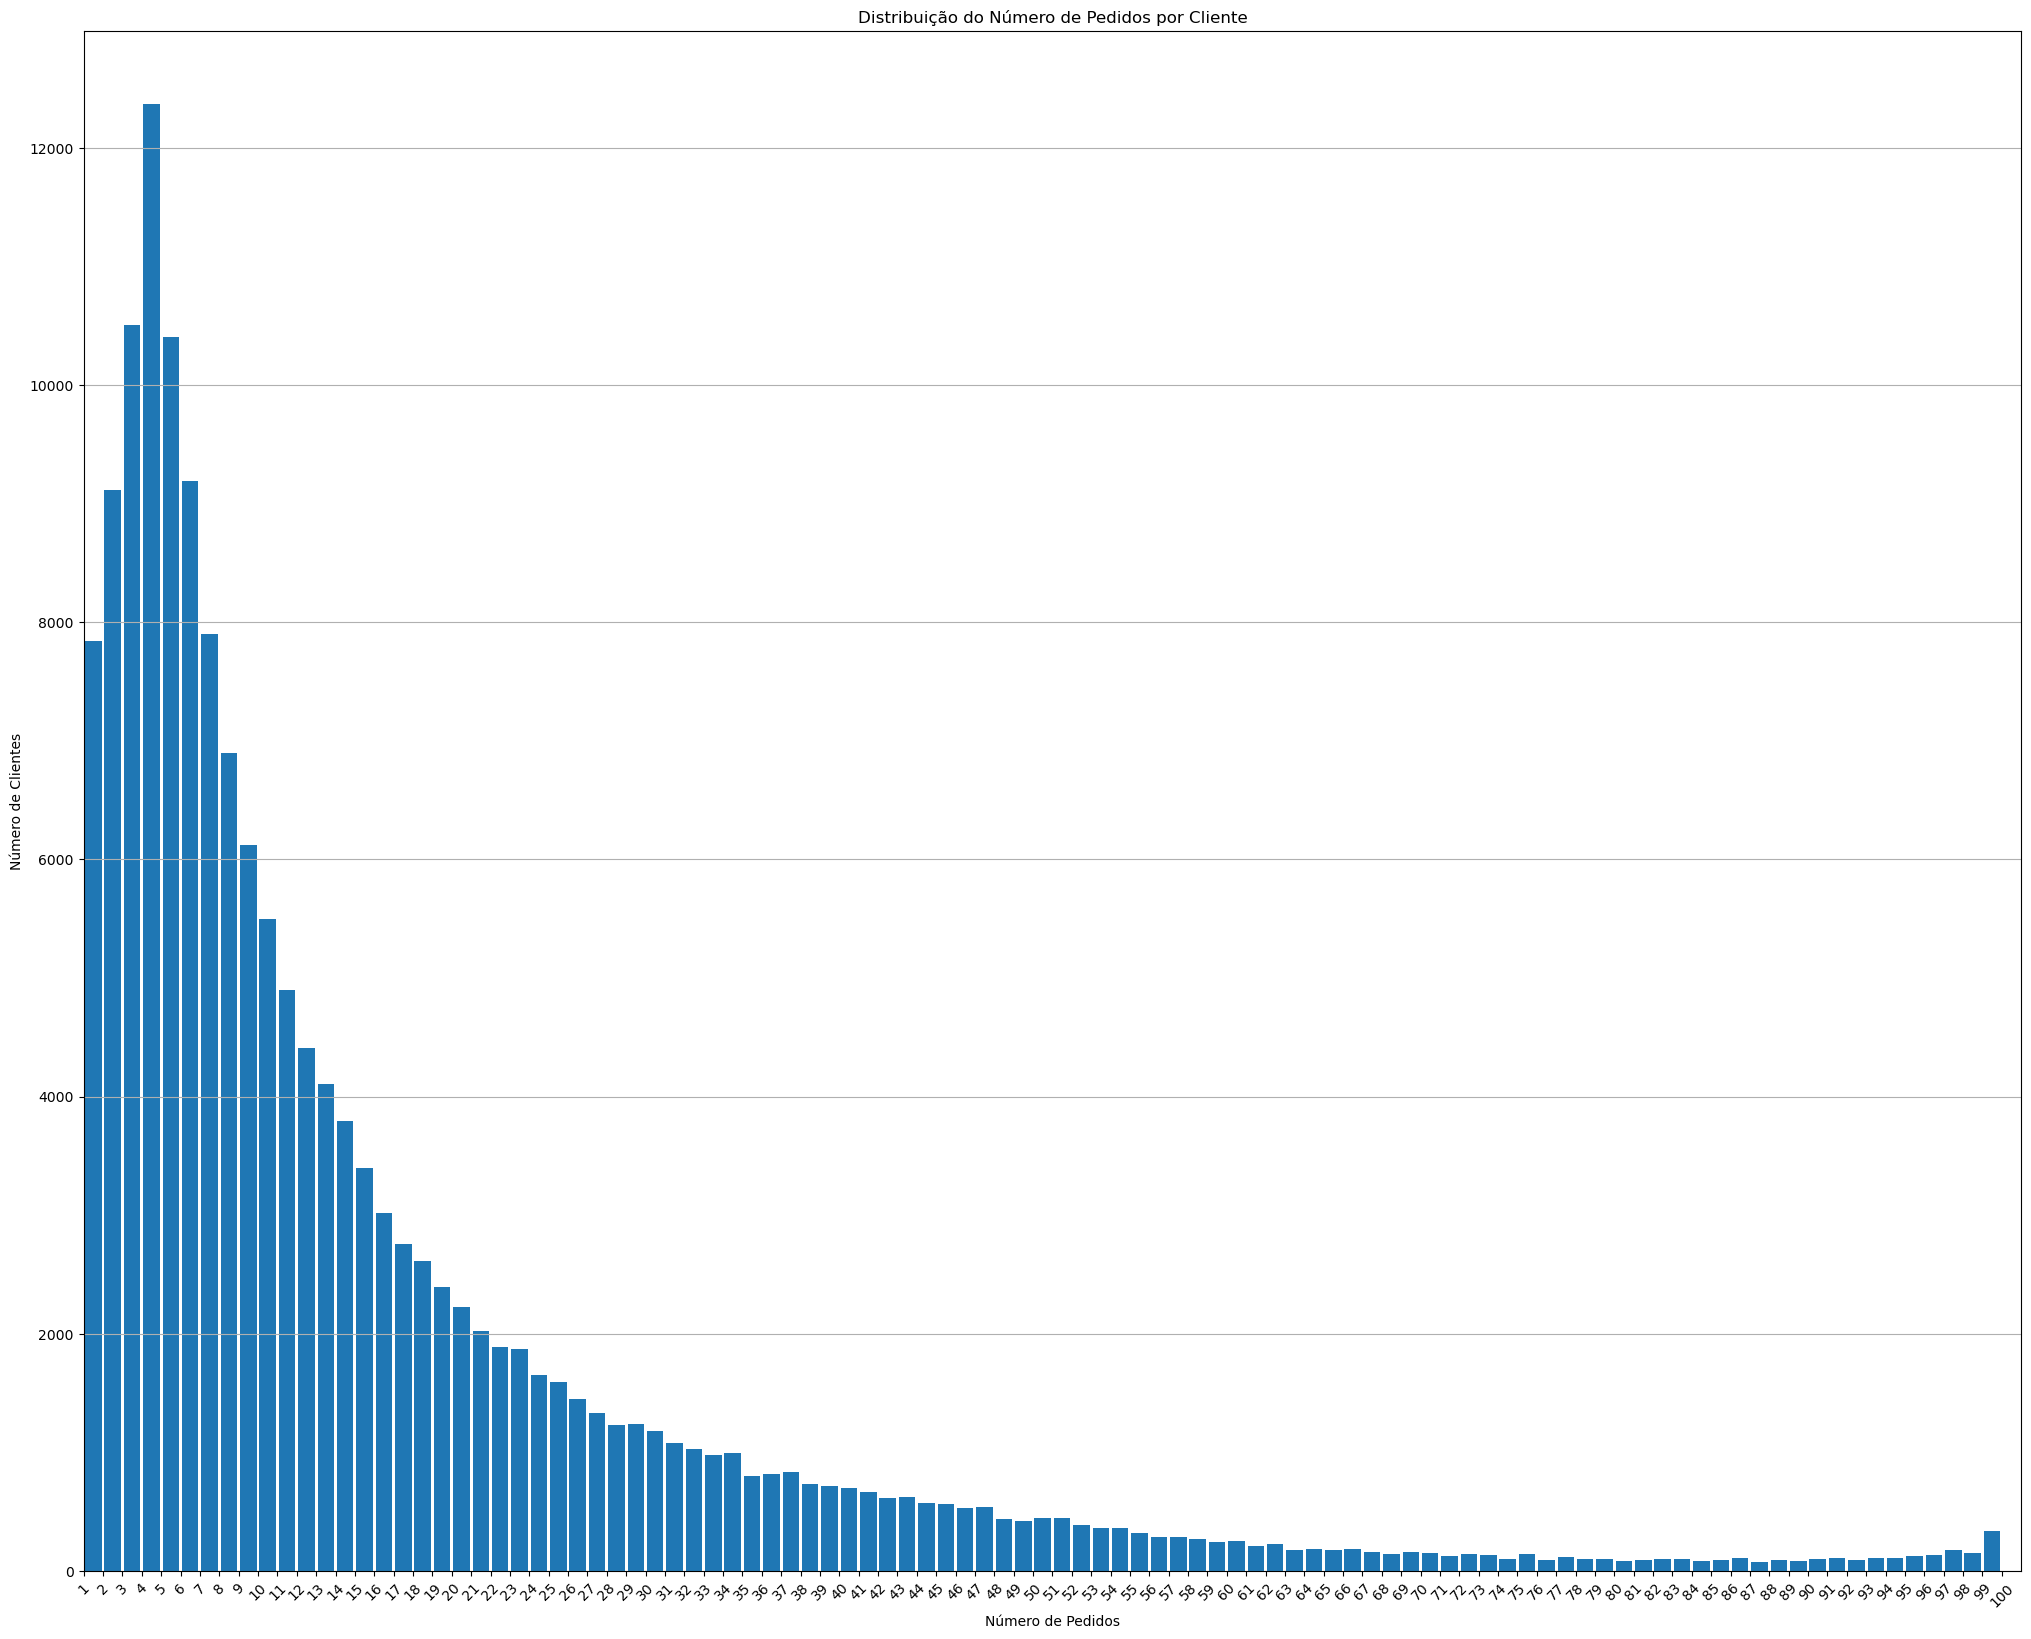

In [43]:
df_orders_by_client = df_instacart_orders.groupby('user_id')['order_number'].max()


#Originalmente eu pretendia plotar o dataframe que criei da forma mais "convencinal" vista no sprint, usando o Pandas, 
#porém após várias tentativas e erros resolvi tentar usando o matplotlib e tive mais sucesso, 
#resolvi manter o código original aqui para análise do que eu poderia ter feito corretamente.


#df_orders_by_client.plot(
#                         kind = 'hist',
#                         title = 'Número de Pedidos por Cliente',
#                         xlabel = 'Número de Pedidos',
#                         ylabel = 'Número de Clientes',
#                         bins = 50,
#                         rwidth = 0.85,
#                         rot = 0,
#                         figsize = [20,15])

#plt.show()


plt.figure(figsize = (25, 20))
plt.hist(df_orders_by_client, bins = range(1, df_orders_by_client.max() + 1), rwidth = 0.85)
plt.title('Distribuição do Número de Pedidos por Cliente')
plt.xlabel('Número de Pedidos')
plt.ylabel('Número de Clientes')
plt.xticks(np.arange(1, df_orders_by_client.max() + 1), rotation = 45)
plt.grid(axis = 'y')
plt.xlim(1, df_orders_by_client.max() + 1)


plt.show()

Escreva suas conclusões aqui

**A grande maioria dos clientes realizou 4 pedidos no total.**

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [44]:
df_top_20_products = df_order_products['product_id'].value_counts().reset_index().head(20)

#NOTA: 'index' na verdade é o valor de 'product_id' e 'product_id' é a contagem de vezes que determinado product_id aparece na dataframe.
print(df_top_20_products)

    product_id  count
0        24852  66050
1        13176  53297
2        21137  37039
3        21903  33971
4        47209  29773
5        47766  24689
6        47626  21495
7        16797  20018
8        26209  19690
9        27845  19600
10       27966  19197
11       22935  15898
12       24964  15292
13       45007  14584
14       39275  13879
15       49683  13675
16       28204  12544
17        5876  12232
18        8277  11993
19       40706  11781


In [64]:
df_top_20_order_products = df_top_20_products.merge(df_products, on = 'product_id')

print(df_top_20_order_products['product_name'])

0                       Banana
1       Bag of Organic Bananas
2         Organic Strawberries
3         Organic Baby Spinach
4         Organic Hass Avocado
5              Organic Avocado
6                  Large Lemon
7                 Strawberries
8                        Limes
9           Organic Whole Milk
10         Organic Raspberries
11        Organic Yellow Onion
12              Organic Garlic
13            Organic Zucchini
14         Organic Blueberries
15              Cucumber Kirby
16          Organic Fuji Apple
17               Organic Lemon
18    Apple Honeycrisp Organic
19      Organic Grape Tomatoes
Name: product_name, dtype: object


Escreva suas conclusões aqui

**Os 20 produtos mais populares se consistem na sua maioria por frutas e verduras, sendo bananas o item mais vendido.**

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

        order_id  num_items
0              4         13
1              9         15
2             11          5
3             19          3
4             20          8
...          ...        ...
450041   3421034         17
450042   3421053          9
450043   3421071          5
450044   3421077          4
450045   3421079          1

[450046 rows x 2 columns]

Valor da moda:
0    5
Name: num_items, dtype: int64


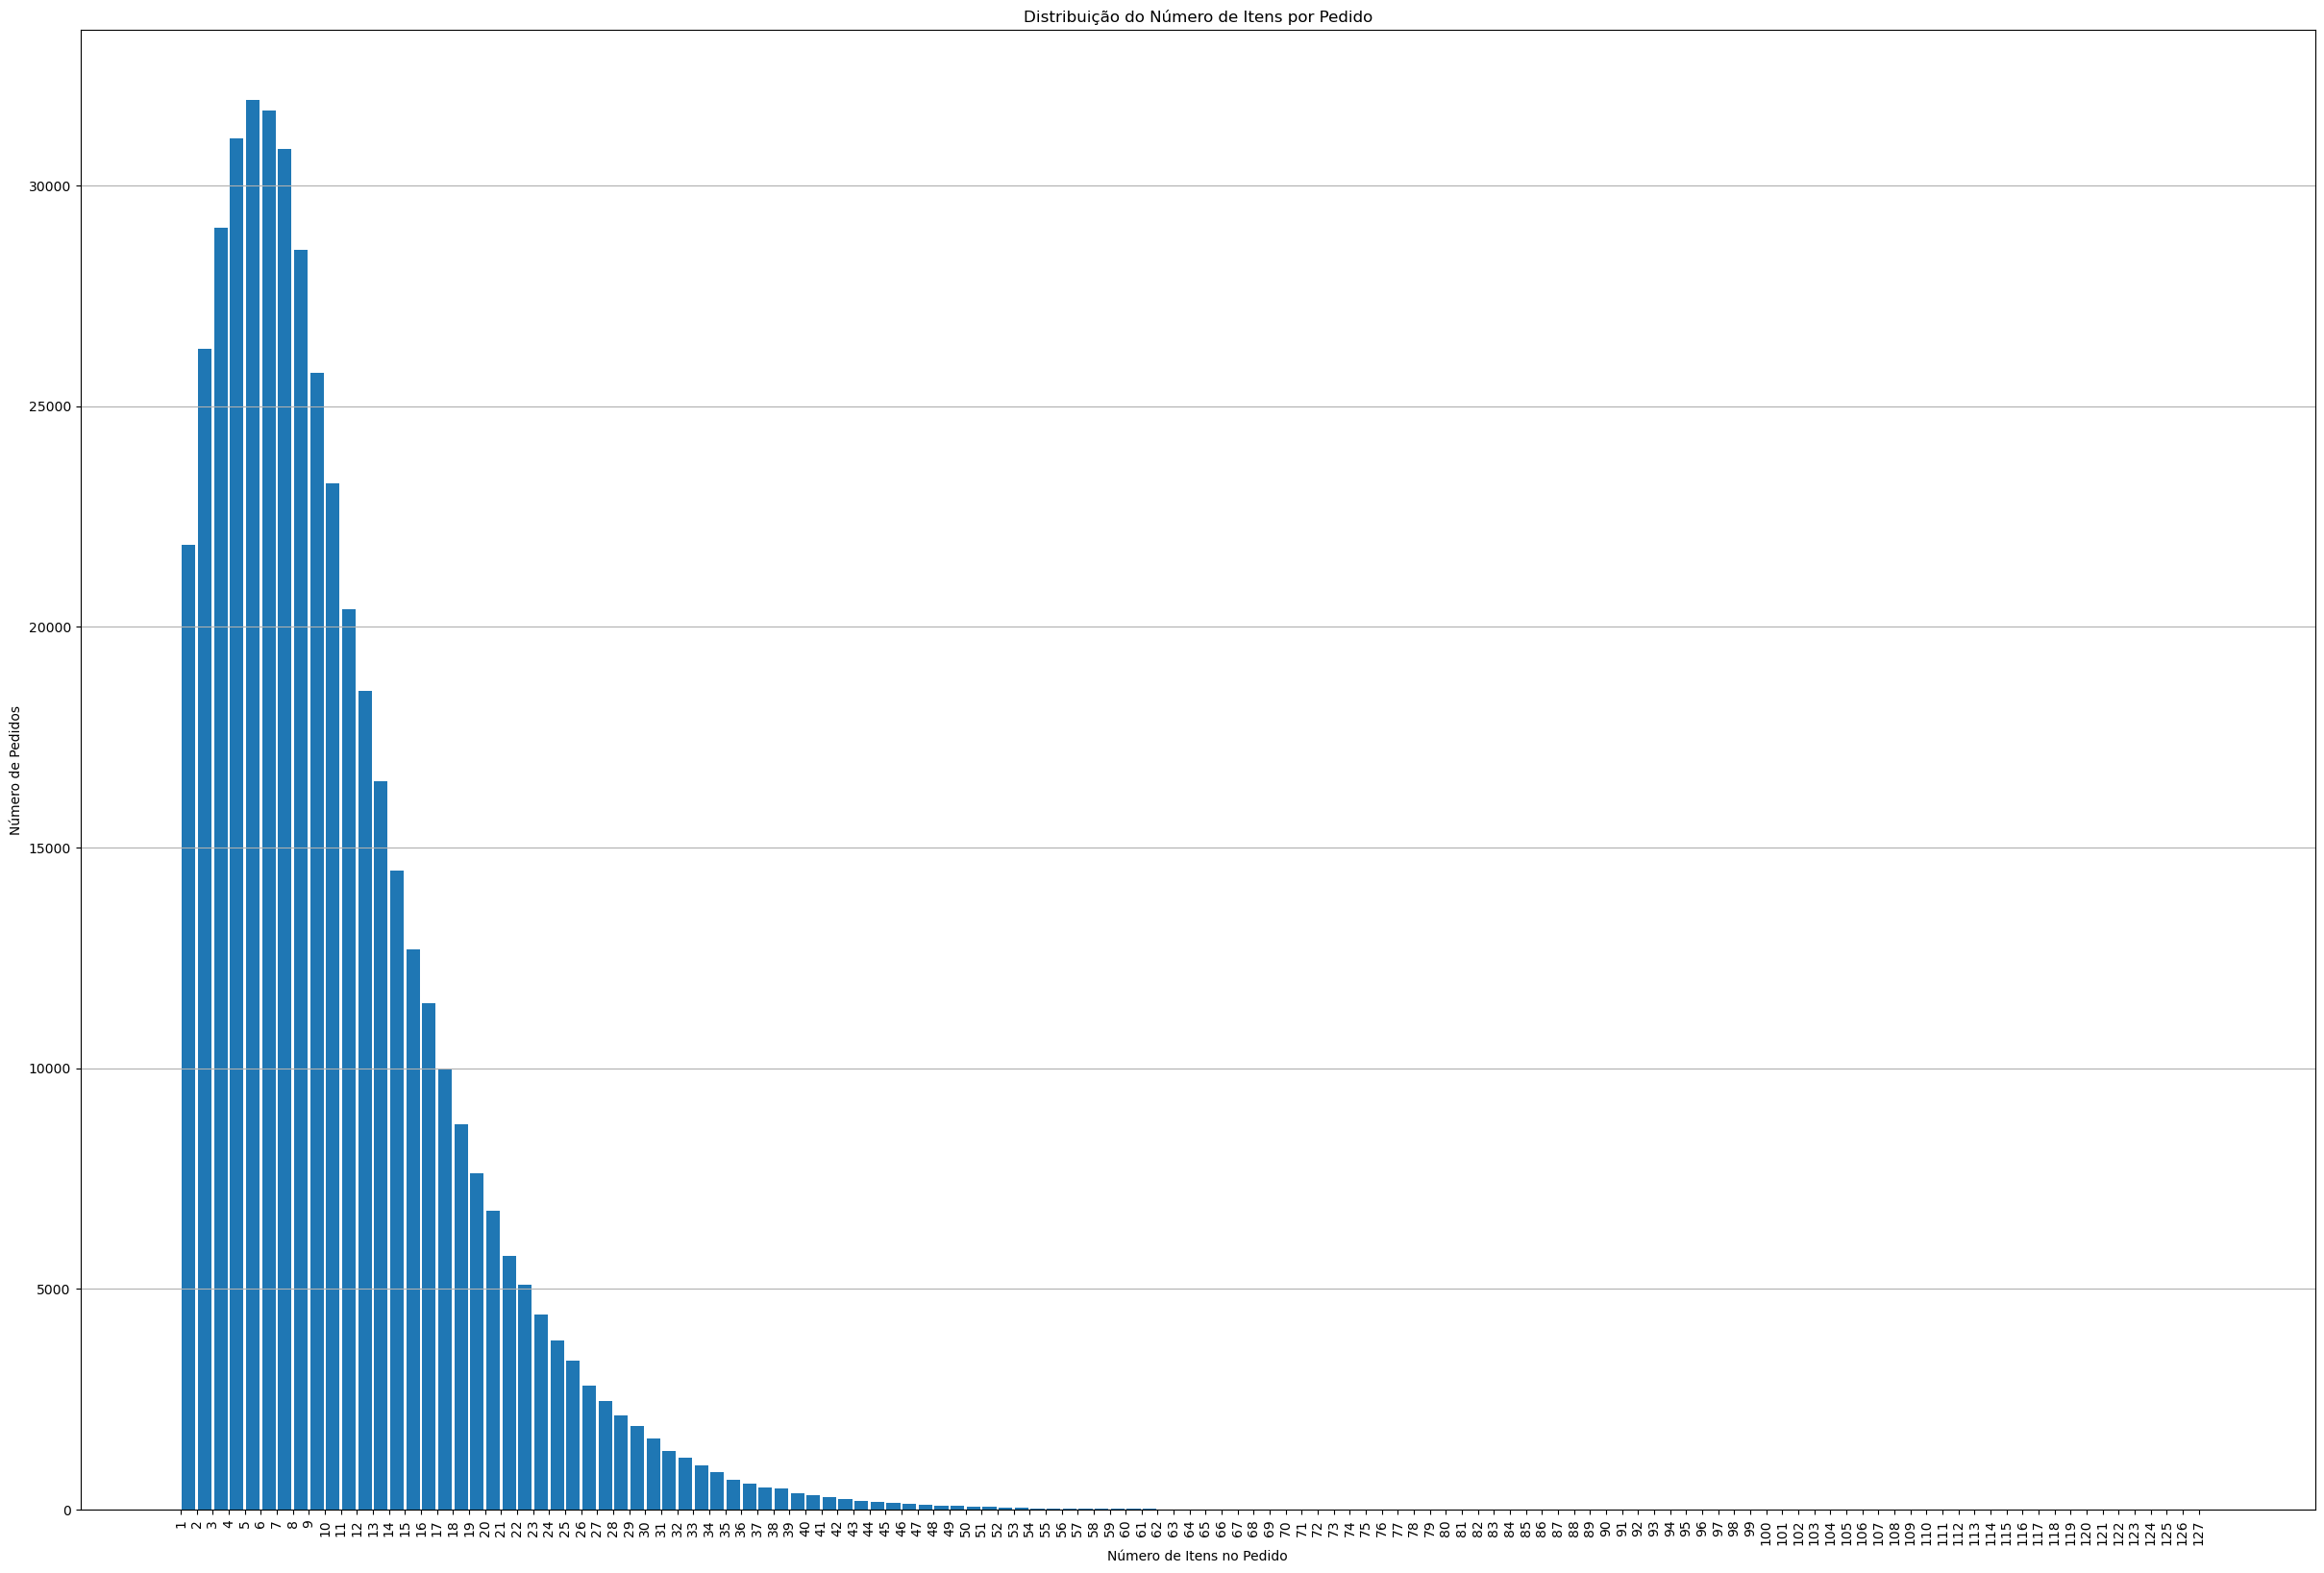

In [49]:
#Agrupa o DataFrame order_products_df por order_id (ou seja, por cada pedido único) e, para cada grupo, conta o número de product_ids.
items_per_order = df_order_products.groupby('order_id')['product_id'].count() 
#Converte a Série para um DataFrame para facilitar a visualização.
df_items_per_order = items_per_order.reset_index(name='num_items') 

# Adquire o valor da moda (valor que mais aparece)
df_mode_items = df_items_per_order['num_items'].mode()

print(df_items_per_order)

print()
print('Valor da moda:')
print(df_mode_items)

plt.figure(figsize = (30, 20))
plt.hist(df_items_per_order['num_items'], bins = range(1, df_items_per_order['num_items'].max() + 2), rwidth = 0.85)
plt.title('Distribuição do Número de Itens por Pedido')
plt.xlabel('Número de Itens no Pedido')
plt.ylabel('Número de Pedidos')
plt.xticks(range(1, df_items_per_order['num_items'].max() + 1), rotation = 90)
plt.grid(axis='y')
plt.show()

Escreva suas conclusões aqui

**A grande maioria dos clientes compra por volta de 5 produtos por pedido.**

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [50]:
#cria um novo dataframe contendo apenas as linhas onde a coluna 'reordered' é 1, significando que o produto foi comprado novamente.
df_reordered_items = df_order_products[df_order_products['reordered'] == 1] 

print(df_reordered_items)

         order_id  product_id  add_to_cart_order  reordered
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          491251        8670                 35          1
4         2571142        1940                  5          1
5         2456893       21616                  4          1
...           ...         ...                ...        ...
4544999   1622300       24852                  1          1
4545000   1125324       40600                  6          1
4545002    577211       15290                 12          1
4545004    692640       47766                  4          1
4545005    319435         691                  8          1

[2683838 rows x 4 columns]


In [51]:
#Conta a ocorrência de cada product_id no dataframe filtrado. #O .reset_index() transforma a Series resultante em um DataFrame para facilitar a manipulação.
df_top_reordered_product_ids = df_reordered_items['product_id'].value_counts().reset_index()

#Renomeia as Colunas 'index' e 'product_id' por 'product_id e 'reorder_count' respectivamente.
df_top_reordered_product_ids.columns = ['product_id', 'reorder_count']                       
print(df_top_reordered_product_ids)                                                          

print()

#seleciona as 20 primeiras linhas do DataFrame, que correspondem aos produtos pedidos novamente com mais frequência.
df_reordered_top_20 = df_top_reordered_product_ids.head(20) 
print(df_reordered_top_20)

       product_id  reorder_count
0           24852          55763
1           13176          44450
2           21137          28639
3           21903          26233
4           47209          23629
...           ...            ...
36223       40133              1
36224       12061              1
36225       45095              1
36226       46185              1
36227       47673              1

[36228 rows x 2 columns]

    product_id  reorder_count
0        24852          55763
1        13176          44450
2        21137          28639
3        21903          26233
4        47209          23629
5        47766          18743
6        27845          16251
7        47626          15044
8        27966          14748
9        16797          13945
10       26209          13327
11       22935          11145
12       24964          10411
13       45007          10076
14       49683           9538
15       28204           8989
16        8277           8836
17       39275           8799
18     

In [52]:
#Combina o DataFrame dos 20 principais IDs de produtos reordenados com o DataFrame products, usando product_id como a chave comum.
df_reordered_top_20_with_names = df_reordered_top_20.merge(df_products, on = 'product_id', how = 'left') 

print(df_reordered_top_20_with_names)

    product_id  reorder_count              product_name  aisle_id  \
0        24852          55763                    Banana        24   
1        13176          44450    Bag of Organic Bananas        24   
2        21137          28639      Organic Strawberries        24   
3        21903          26233      Organic Baby Spinach       123   
4        47209          23629      Organic Hass Avocado        24   
5        47766          18743           Organic Avocado        24   
6        27845          16251        Organic Whole Milk        84   
7        47626          15044               Large Lemon        24   
8        27966          14748       Organic Raspberries       123   
9        16797          13945              Strawberries        24   
10       26209          13327                     Limes        24   
11       22935          11145      Organic Yellow Onion        83   
12       24964          10411            Organic Garlic        83   
13       45007          10076     

In [53]:
print(df_reordered_top_20_with_names[['product_id', 'product_name', 'reorder_count']])

    product_id              product_name  reorder_count
0        24852                    Banana          55763
1        13176    Bag of Organic Bananas          44450
2        21137      Organic Strawberries          28639
3        21903      Organic Baby Spinach          26233
4        47209      Organic Hass Avocado          23629
5        47766           Organic Avocado          18743
6        27845        Organic Whole Milk          16251
7        47626               Large Lemon          15044
8        27966       Organic Raspberries          14748
9        16797              Strawberries          13945
10       26209                     Limes          13327
11       22935      Organic Yellow Onion          11145
12       24964            Organic Garlic          10411
13       45007          Organic Zucchini          10076
14       49683            Cucumber Kirby           9538
15       28204        Organic Fuji Apple           8989
16        8277  Apple Honeycrisp Organic        

Escreva suas conclusões aqui

**A grande maioria das compras repetidas se consistem em frutas e verduras, com o produto mais recomprado sendo bananas.**

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [54]:
#Agrupa os dados por product_id e conta o número total de vezes que cada produto aparece em order_products. O .reset_index(name='total_orders') converte o resultado em um dataframe com uma coluna chamada total_orders.
df_orders_per_product = df_order_products.groupby('product_id').size().reset_index(name = 'total_orders') 

#Agrupa os dados por product_id e soma os valores da coluna reordered. Soma reordered para obter o número de vezes que o produto foi recomprado.
df_reordered_product_count = df_order_products.groupby('product_id')['reordered'].sum().reset_index(name = 'reordered_count')

print(df_orders_per_product)
print()
print(df_reordered_product_count)
                                                                                                                                 

       product_id  total_orders
0               1           280
1               2            11
2               3            42
3               4            49
4               7             2
...           ...           ...
45568       49690             5
45569       49691            72
45570       49692            12
45571       49693            25
45572       49694             9

[45573 rows x 2 columns]

       product_id  reordered_count
0               1              158
1               2                0
2               3               31
3               4               25
4               7                1
...           ...              ...
45568       49690                4
45569       49691               31
45570       49692                5
45571       49693               11
45572       49694                3

[45573 rows x 2 columns]


In [55]:
#Combina os dois dataframes resultantes usando product_id como chave.
product_reorder_data = df_orders_per_product.merge(df_reordered_product_count, on='product_id')

#Cria uma nova coluna chamada 'reorder_percentage' dividindo reordered_count por total_orders e multiplicando por 100 para obter a porcentagem.
product_reorder_data['reorder_percentage'] = (product_reorder_data['reordered_count'] / product_reorder_data['total_orders']) * 100

print(product_reorder_data)

       product_id  total_orders  reordered_count  reorder_percentage
0               1           280              158           56.428571
1               2            11                0            0.000000
2               3            42               31           73.809524
3               4            49               25           51.020408
4               7             2                1           50.000000
...           ...           ...              ...                 ...
45568       49690             5                4           80.000000
45569       49691            72               31           43.055556
45570       49692            12                5           41.666667
45571       49693            25               11           44.000000
45572       49694             9                3           33.333333

[45573 rows x 4 columns]


In [56]:
#Combina o dataframe com as estatísticas de recompra com o dataframe products para adicionar o product_name correspondente a cada product_id.
product_reorder_data_with_names = product_reorder_data.merge(df_products[['product_id', 'product_name']], on = 'product_id')


#Reordena o dataframe em ordem decrescente pela reorder_percentage para visualizar os produtos mais recomprados primeiro.
product_reorder_data_with_names_in_order = product_reorder_data_with_names.sort_values(by='reordered_count', ascending = False)

print(product_reorder_data_with_names)
print()
print(product_reorder_data_with_names_in_order.head(20))

       product_id  total_orders  reordered_count  reorder_percentage  \
0               1           280              158           56.428571   
1               2            11                0            0.000000   
2               3            42               31           73.809524   
3               4            49               25           51.020408   
4               7             2                1           50.000000   
...           ...           ...              ...                 ...   
45568       49690             5                4           80.000000   
45569       49691            72               31           43.055556   
45570       49692            12                5           41.666667   
45571       49693            25               11           44.000000   
45572       49694             9                3           33.333333   

                                            product_name  
0                             Chocolate Sandwich Cookies  
1                

Escreva suas conclusões aqui

**A grande maioria dos produtos repetidos são alimentos fitness, como frutas e verduras, com o mais comprado sendo Bananas.**

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [57]:
#cria um novo dataframe que agrupa as colunas 'order_id' e 'reordered'. Usa-se .max() na coluna reordered, assim, se qualquer produto naquele pedido tiver reordered como 1, o resultado de .max() será 1, indicando que o pedido contêm pelo menos um item repetido. Se todos os produtos do pedido tiverem reordered como 0, o resultado será 0. Renomeia a coluna 'reordered' por 'has_reordered_product'.
df_reordered_orders = df_order_products.groupby('order_id')['reordered'].max().reset_index(name = 'has_reordered_product')

#Cria um novo dataframe junta 'df_reordered_products' e 'df_instacart_orders' usando a coluna 'order_id' como chave
df_reordered_orders_with_users = df_instacart_orders.merge(df_reordered_orders, on = 'order_id', how = 'left')
print(df_reordered_orders_with_users)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
0        1515936   183418            11          6                 13   
1        1690866   163593             5          5                 12   
2        1454967    39980             4          5                 19   
3        1768857    82516            56          0                 20   
4        3007858   196724             2          4                 12   
...          ...      ...           ...        ...                ...   
478947   3210681     5617             5          1                 14   
478948   3270802   112087             2          3                 13   
478949    885349    82944            16          2                 11   
478950    216274     4391             3          3                  8   
478951   2071924     1730            18          1                 14   

        days_since_prior_order  has_reordered_product  
0                         30.0                    1.0  
1          

In [58]:
#cria o dataframe 'df_user_reorder_proportion' que irá calcular a proporção de pedidos repetidos por cliente agrupando 'user_id' e 'has_reordered_product'
df_user_reorder_proportion = df_reordered_orders_with_users.groupby('user_id')['has_reordered_product'].agg(
    total_reordered_orders = 'sum', #Soma todos os pedidos com um produto repetido (1s)
    total_orders = 'count' #Conta todos os pedidos do usuário
).reset_index()

#cria a coluna 'proportion_reordered_orders' que é o resultado da divisão dps valores das colunas 'total_reordered_orders' e 'total_orders'
df_user_reorder_proportion['proportion_reordered_orders'] = df_user_reorder_proportion['total_reordered_orders'] / df_user_reorder_proportion['total_orders']

print(df_user_reorder_proportion.head(50))

    user_id  total_reordered_orders  total_orders  proportion_reordered_orders
0         2                     1.0             2                     0.500000
1         4                     0.0             1                     0.000000
2         5                     1.0             1                     1.000000
3         6                     0.0             1                     0.000000
4         7                     2.0             2                     1.000000
5        10                     0.0             0                          NaN
6        11                     1.0             1                     1.000000
7        12                     1.0             1                     1.000000
8        13                     2.0             3                     0.666667
9        14                     3.0             3                     1.000000
10       15                     4.0             5                     0.800000
11       16                     3.0             3   

Escreva suas conclusões aqui

**Consultar o dataframe df_user_reorder_proportion.**

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [59]:
#Cria o dataframe 'df_first_added_items' e filtra apenas os itens que foram adicionados primeiro ao carrinho (add_to_cart_order = 1) da dataframe 'df_order_products'
df_first_added_items = df_order_products[df_order_products['add_to_cart_order'] == 1]

#Conta todas as vezes que cada produto foi adicionado primeiro
df_first_added_count = df_first_added_items['product_id'].value_counts().reset_index()
#Renomeia as colunas 'index' e 'product_id' por 'product_id' e 'first_total' respectivamente
df_first_added_count.columns = ['product_id', 'first_total']

print(df_first_added_count)

       product_id  first_total
0           24852        15562
1           13176        11026
2           27845         4363
3           21137         3946
4           47209         3390
...           ...          ...
26755       19379            1
26756       45509            1
26757       27173            1
26758       48704            1
26759       43804            1

[26760 rows x 2 columns]


In [60]:
#Cria o dataframe 'df_top_20_first_items' juntado as colunas de 'df_first_added_count' com 'df_products' usando 'product_id' como chave e seleciona apenas as 20 primeiras linhas.
df_top_20_first_items = df_first_added_count.merge(df_products, on = 'product_id').head(20)

In [61]:
#Imprime as colunas 'product_id', 'product_name' e 'first_total'
print(df_top_20_first_items[['product_id', 'product_name', 'first_total']])

    product_id                 product_name  first_total
0        24852                       Banana        15562
1        13176       Bag of Organic Bananas        11026
2        27845           Organic Whole Milk         4363
3        21137         Organic Strawberries         3946
4        47209         Organic Hass Avocado         3390
5        21903         Organic Baby Spinach         3336
6        47766              Organic Avocado         3044
7        19660                 Spring Water         2336
8        16797                 Strawberries         2308
9        27966          Organic Raspberries         2024
10       44632   Sparkling Water Grapefruit         1914
11       49235          Organic Half & Half         1797
12       47626                  Large Lemon         1737
13         196                         Soda         1733
14       38689     Organic Reduced Fat Milk         1397
15       26209                        Limes         1370
16       12341                H

Escreva suas conclusões aqui

**Os 20 produtos que mais são adicionados em primeiro lugar no carrinho são em sua maioria alimentos fitness, como frutas, verduras, água e leite.**

# Conclusão geral do projeto:

**Após analisar os dados de todos os 5 dataframes, pude concluir que a grande maioria das compras feitas no Instacart são em sua maioria de alimentos fitiness como frutas e verduras, e seu item mais vendido é bananas.**